In [ ]:
%load_ext autoreload 
%autoreload 2

import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(os.path.join(os.getcwd(), ".."))

import math
import numpy as np
import pandas as pd
from numpy import array
from numpy import array, arange, abs as np_abs
from numpy.fft import rfft, rfftfreq
from math import sin, pi
from scipy import signal
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from tqdm import tqdm

import importlib
import model as md
import view as vw

importlib.reload(md)
importlib.reload(vw)

from model.relevant_methods import phase_methods

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\notebooks\Complex_ms\Big_statistics\..


<module 'view' from 'c:\\Users\\Артем\\Desktop\\Вуз\\Аспирантура\\Диссертация\\Алгоритм\\Relaxation_frequency_phase_algorithm\\view\\__init__.py'>

In [9]:
def get_phase_LI(
        time,
        sig1,
        sig2,
        f0=None,
        win_size=None,
        hop_size=None
    ):
    def get_phase_solo(t, wave):
        ref_sin = np.sin(2*np.pi*f0*time)
        ref_cos = np.cos(2*np.pi*f0*time)

        I = np.mean(wave * ref_cos)
        Q = np.mean(wave * ref_sin)

        phi = np.rad2deg(np.arctan2(Q, I))
        return phi
        
    phase1=get_phase_solo(time,sig1)
    phase2=get_phase_solo(time,sig2)
    dela_phase = phase2 - phase1

    return dela_phase

In [10]:
def variate_phase(F, phase_method,SNR=60,fs_mult=15, bits=12 ,duration_T=130,gen_unstable=1):
    phases_range = np.linspace(0,179,179)
    phases = []

    for phase_real in phases_range:
        
        duration = duration_T / F
        fs = F * fs_mult

        t = np.linspace(0, duration, int(duration * fs))

        phase = md.generate_common_phase(
            t,
            F,
            gen_unstable,
            phase0_deg=0
        )

        # 2. Сигналы с заданной фазовой разницей
        U, I = md.generate_signals_from_phase(
            phase,
            phase_diff_deg=phase_real
        )
        
        U = md.add_SNR(U, SNR)
        I = md.add_SNR(I, SNR)

        U=md.adc_quantize(U,int(bits),1)
        I=md.adc_quantize(I,int(bits),1)

        phase_mes = phase_method(t, U, I, F)
        phase_error = abs(phase_mes) - abs(phase_real)

        phases.append(abs(phase_error))

    phase_min=min(phases)
    phase_max=max(phases)
    phase_mean=np.mean(phases)
    phase_kde=md.get_kde_mode(phases)

    return phase_min,phase_max,phase_mean,phase_kde

In [11]:
def variate_methods(phase_methods,fs_mult=15,duration_T=130, bits=12 ,gen_unstable=1):

    F=440e3
    div_mins=[]
    div_maxs=[]
    div_means=[]
    div_kdes=[]
    for method in phase_methods:
        div_min=[]
        div_max=[]
        div_mean=[]
        div_kde=[]

        SNR_range=range(10,100,5)

        for SNR in tqdm(SNR_range, desc=f"Метод {method.__name__}", unit=" шага"):
            phase_min,phase_max,phase_mean,phase_kde=variate_phase(F,method,SNR,fs_mult,bits,duration_T,gen_unstable)
            div_kde.append(phase_kde)
            div_max.append(phase_max)
            div_min.append(phase_min)
            div_mean.append(phase_mean)

        div_kdes.append(div_kde)
        div_maxs.append(div_max)
        div_mins.append(div_min)
        div_means.append(div_mean)

    return SNR_range, div_min, div_max, div_means, div_kdes

In [23]:
def clean_name(func):
    return func.__name__.replace("get_phase_", "").replace("get_phase", "")

def plot_methods_snr(SNR_range, div_kdes,phase_methods):
    fig = plt.figure(figsize=(6, 8))
    gs = fig.add_gridspec(2, 1)
    front = 12
    ax1 = fig.add_subplot(gs[0, 0])
    
    method_names = [clean_name(m) for m in phase_methods]
    
    for i in range(0,len(phase_methods),1):
        ax1.plot(SNR_range,div_kdes[i], label=method_names[i])

    ax1.legend()
    ax1.set_yscale('log')
    ax1.grid()

    ax1.set_xlabel('SNR', fontsize=front)
    ax1.set_ylabel('Delta phase °', fontsize=front)

def plot_methods_snr_black(SNR_range, div_kdes, phase_methods):
    fig = plt.figure(figsize=(6, 8))
    gs = fig.add_gridspec(2, 1)
    front = 12
    ax1 = fig.add_subplot(gs[0, 0])
    method_names = [clean_name(m) for m in phase_methods]
    
    # Списки стилей для ЧБ
    linestyles = ['-', '--', '-.', ':', (0, (3,1,1,1))]
    markers = ['o', 's', '^', 'd', 'x', 'p','*']

    for i in range(len(phase_methods)):
        # Рассчитываем шаг для маркеров (например, чтобы их было ~10-12 штук)
        step = max(len(SNR_range) // 12, 1)
        
        ax1.plot(
            SNR_range, 
            div_kdes[i], 
            label=method_names[i],
            color='black',                           # Черный цвет линии
            linestyle=linestyles[i % len(linestyles)], # Разные типы линий
            marker=markers[i % len(markers)],        # Разные маркеры
            markerfacecolor='white',                 # Белая заливка (лучше видно на ЧБ)
            markeredgecolor='black',                 # Черный контур маркера
            markersize=5,
            markevery=step                           # Редкие маркеры для чистоты
        )

    # Настройка легенды (выносим чуть-чуть, чтобы не мешала)
    ax1.legend(fontsize=10, frameon=True)
    ax1.set_yscale('log')
    
    # Сетка (делаем её пунктирной и светлой, чтобы не спорила с графиками)
    ax1.grid(True, linestyle='--', alpha=0.6)

    ax1.set_xlabel('SNR', fontsize=front)
    ax1.set_ylabel('Delta phase °', fontsize=front)
    
    plt.tight_layout()

Метод get_phase_SWFR: 100%|██████████| 18/18 [00:03<00:00,  5.72 шага/s]


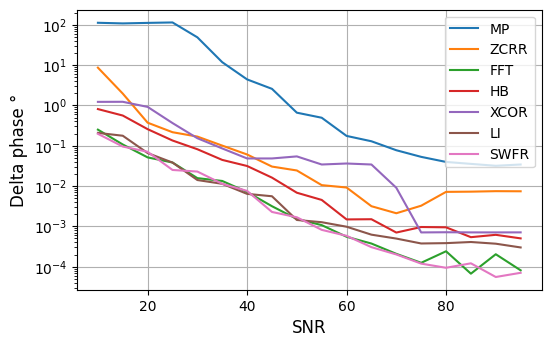

In [ ]:
SNR_range, div_min, div_max, div_means, div_kdes =variate_methods(phase_methods,60,60)

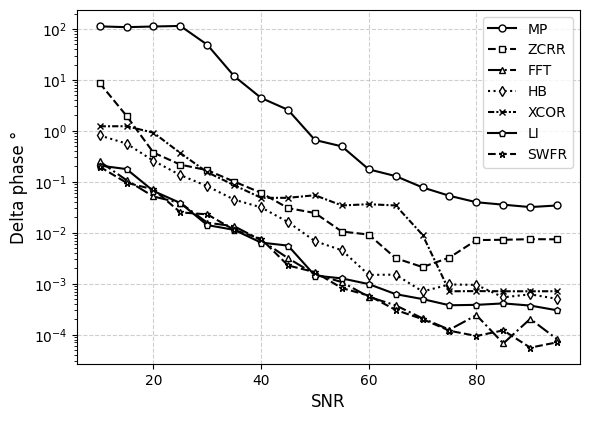

In [25]:
plot_methods_snr_black(SNR_range, div_kdes,phase_methods)